# Protein Secondary Structure Prediction Analysis

This notebook evaluates the models for this project and tests them against the technical requirements (as provided in the problem statement).

## 1. Imports & Setup <a id='Imports'></a>

In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tqdm.notebook import tqdm
import time
import os
from pathlib import Path
from torch.utils.data import DataLoader
from config import config
from models.bilstm import BiLSTM_Model

## 2. Evaluation

In [ ]:
def evaluate_model(model_type, device = config['device'], load_best_model = False):
    if model_type == "esm":
        from datasets.dataset_esm import ESM_Embedding_Dataset as Dataset
        model = BiLSTM_Model(
            hidden_dim=config[model_type]['hidden_dim'],
            num_layers=config[model_type].get('num_layers', 2),
            use_pretrained_embeddings=True
        ).to(device)
    else:
        from datasets.dataset_bilstm import PrepareCB513 as Dataset
        model = BiLSTM_Model(
            hidden_dim=config[model_type]['hidden_dim'],
            num_layers=config[model_type].get('num_layers', 2),
            use_pretrained_embeddings=False
        ).to(device)    

    checkpoint_dir = "checkpoints"
    matching_ckpts = [
        os.path.join(checkpoint_dir, f)
        for f in os.listdir(checkpoint_dir)
        if f.startswith(model_type) and f.endswith(".pt")
    ]
    if not matching_ckpts:
        raise FileNotFoundError(f"No checkpoints found for '{model_type}' in '{checkpoint_dir}'.")

    ckpt_path = max(matching_ckpts, key=os.path.getmtime)
    print(f"Loading checkpoint: {ckpt_path}")

    state_dict = torch.load(ckpt_path, map_location=device, weights_only=True)
    try:
        model.load_state_dict(state_dict, strict=True)
    except RuntimeError as e:
        print(f"Warning: {str(e)}")
        print("Attempting to load with strict=False...")
        model.load_state_dict(state_dict, strict=False)

    model.eval()
    print(f"Model loaded successfully with architecture: hidden_dim={model.bilstm.hidden_size}, num_layers={model.bilstm.num_layers}")
    
    dataset = Dataset()
    loader = DataLoader(dataset, batch_size=config[model_type]["batch_size"], shuffle=False)
    
    start_time = time.time()
    
    true_labels = []
    pred_labels = []

    with torch.no_grad():
        for xb, yb in tqdm(loader, desc="Evaluating", unit="batch"):
            xb, yb = xb.to(device), yb.to(device)
            output = model(xb)
            _, preds = torch.max(output, 1)
            
            true_labels.extend(yb.cpu().numpy())
            pred_labels.extend(preds.cpu().numpy())
    
    eval_time = time.time() - start_time

    print(f"Evaluation time: {eval_time:.2f}s\n")
    
    report = classification_report(
        true_labels, pred_labels, 
        target_names=["H", "E", "C"],
        output_dict=True
    )
    cm = confusion_matrix(true_labels, pred_labels)
    
    return {
        "model_type": model_type,
        "accuracy": accuracy_score(true_labels, pred_labels),
        "report": report,
        "confusion_matrix": cm,
        "evaluation_time": eval_time,
        "samples": len(true_labels)
    }

In [3]:
print(f"Using device: {config['device']}")

results = {}
for model_type in ["bilstm", "esm"]:
    try:
        results[model_type] = evaluate_model(model_type)
    except Exception as e:
        print(f"Error evaluating {model_type}: {e}")

Using device: cuda
Loading checkpoint: checkpoints\bilstm_20250720_160827.pt
Model loaded successfully with architecture: hidden_dim=128, num_layers=3
Evaluation time: 4.21s

Loading checkpoint: checkpoints\esm_20250720_162144.pt
Model loaded successfully with architecture: hidden_dim=128, num_layers=2
Evaluation time: 72.90s



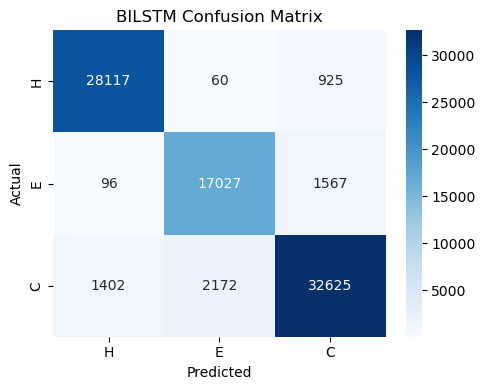

Saved bilstm_conf_matrix.png


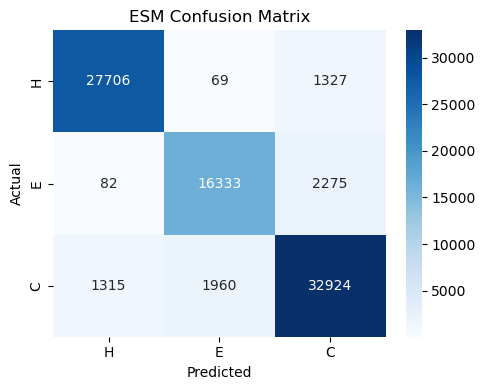

Saved esm_conf_matrix.png


In [4]:
def plot_confusion_matrices(results):
    os.makedirs("results/eval_reports", exist_ok=True)

    for model_type, data in results.items():
        fig, ax = plt.subplots(figsize=(5, 4))
        sns.heatmap(
            data["confusion_matrix"], 
            annot=True, 
            fmt="d", 
            cmap="Blues",
            xticklabels=["H", "E", "C"],
            yticklabels=["H", "E", "C"],
            ax=ax
        )
        ax.set_title(f"{model_type.upper()} Confusion Matrix")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        plt.tight_layout()
        plt.show()
        plt.savefig(f"results/eval_reports/{model_type}_conf_matrix.png", dpi=300)
        print(f"Saved {model_type}_conf_matrix.png")
        plt.close()

plot_confusion_matrices(results)


## 5. Class-wise Performance

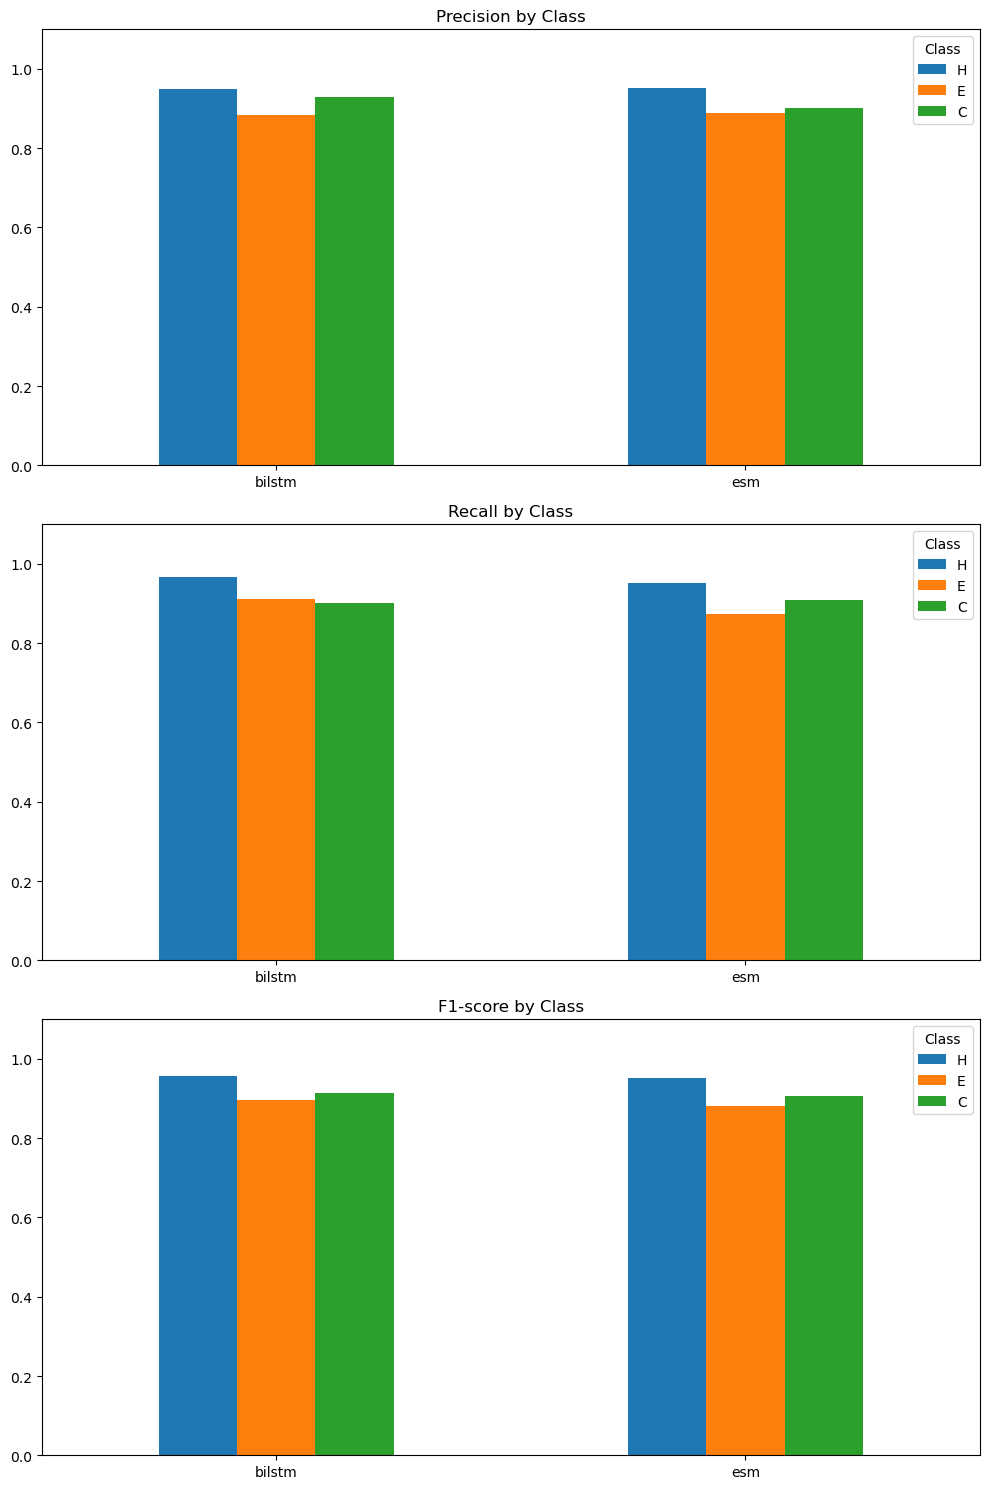

In [5]:
def plot_class_performance(results):

    metrics = ["precision", "recall", "f1-score"]
    fig, axes = plt.subplots(3, 1, figsize=(10, 15))
    
    for i, metric in enumerate(metrics):
        df = pd.DataFrame({
            "H": [results[m]["report"]["H"][metric] for m in results],
            "E": [results[m]["report"]["E"][metric] for m in results],
            "C": [results[m]["report"]["C"][metric] for m in results]
        }, index=results.keys())
        
        df.plot(kind="bar", ax=axes[i], rot=0)
        axes[i].set_title(f"{metric.capitalize()} by Class")
        axes[i].set_ylim(0, 1.1)
        axes[i].legend(title="Class")
    
    plt.tight_layout()
    plt.show()

plot_class_performance(results)

## 6. Testing Accuracy

In [6]:
def compare_models(results):
    comparison = []
    for model_type, data in results.items():
        report = data["report"]
        comparison.append({
            "Model": model_type.upper(),
            "Q3 Accuracy": f"{data['accuracy']*100:.2f}%",
            "Helix (H) F1": f"{report['H']['f1-score']*100:.2f}%",
            "Sheet (E) F1": f"{report['E']['f1-score']*100:.2f}%",
            "Coil (C) F1": f"{report['C']['f1-score']*100:.2f}%",
            "Inference Time": f"{data['evaluation_time']:.2f}s",
            "Samples": data["samples"]
        })

    # store comparison data
    os.makedirs("results/eval_reports", exist_ok=True)
    for model_type, data in results.items():
        comparison_df = pd.DataFrame([data])
        comparison_df.to_csv(f"results/eval_reports/{model_type}_metrics.csv", index=False)

    return pd.DataFrame(comparison)

comparison_df = compare_models(results)
display(comparison_df)


,Model,Q3 Accuracy,Helix (H) F1,Sheet (E) F1,Coil (C) F1,Inference Time,Samples
0,BILSTM,92.59%,95.77%,89.74%,91.49%,4.21s,83991
1,ESM,91.63%,95.20%,88.16%,90.54%,72.90s,83991


Q3 Accuracy is >85% for both versions.

## 7. Testing Efficiency
We will be testing both models on a protein sequence containing 1000 residues.

In [7]:

def test_efficiency(model_type, device, target_residues=1000):

    if model_type == "esm":
        from datasets.dataset_esm import ESM_Embedding_Dataset as Dataset
        model = BiLSTM_Model(use_pretrained_embeddings=True).to(device)
    else:
        from datasets.dataset_bilstm import PrepareCB513 as Dataset
        model = BiLSTM_Model(use_pretrained_embeddings=False).to(device)

    # Load model
    checkpoint_dir = Path("checkpoints")
    ckpt_path = max((p for p in checkpoint_dir.glob(f"{model_type}_*.pt")), key=os.path.getmtime)
    model.load_state_dict(torch.load(ckpt_path, map_location=device, weights_only=True), strict=False)
    model.eval()

    dataset = Dataset()
    loader = DataLoader(dataset, batch_size=1, shuffle=False)

    total_residues = 0
    timed_batches = []
    start_time = time.time()

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            batch_residues = yb.numel()
            out = model(xb)
            total_residues += batch_residues
            if total_residues >= target_residues:
                break

    elapsed = time.time() - start_time
    print(f"Model: {model_type.upper()}")
    print(f"Time to infer {total_residues} residues: {elapsed:.3f} sec")

test_efficiency("bilstm", "cuda")
print('\n')
test_efficiency("esm", "cuda")


Model: BILSTM
Time to infer 1000 residues: 1.207 sec


Model: ESM
Time to infer 1000 residues: 1.128 sec


## 8. Testing Interpretability

In [8]:
device = config['device']
model = BiLSTM_Model(use_pretrained_embeddings=True).to(device)

checkpoint_dir = "checkpoints"
matching_ckpts = [
    os.path.join(checkpoint_dir, f)
    for f in os.listdir(checkpoint_dir)
    if f.startswith(model_type) and f.endswith(".pt")
]
if not matching_ckpts:
    raise FileNotFoundError(f"No checkpoints found for '{model_type}' in '{checkpoint_dir}'.")

ckpt_path = max(matching_ckpts, key=os.path.getmtime)
model.load_state_dict(torch.load(ckpt_path, map_location=device, weights_only=True))
model.eval()
print(f"Loaded checkpoint: {os.path.basename(ckpt_path)}")


RuntimeError: Error(s) in loading state_dict for BiLSTM_Model:
	Missing key(s) in state_dict: "bilstm.weight_ih_l2", "bilstm.weight_hh_l2", "bilstm.bias_ih_l2", "bilstm.bias_hh_l2", "bilstm.weight_ih_l2_reverse", "bilstm.weight_hh_l2_reverse", "bilstm.bias_ih_l2_reverse", "bilstm.bias_hh_l2_reverse". 

In [ ]:
dataset = Dataset()
sample_x, sample_y = dataset[0]  # first sample
sample_x = sample_x.unsqueeze(0).to(device)
sample_x.requires_grad = True

# Forward pass
output = model(sample_x)
pred_class = output.argmax(dim=1)
loss = output[0, pred_class]
loss.backward()

# Compute importance scores
importance = sample_x.grad.abs().mean(dim=-1).detach().cpu().numpy().flatten()
importance = (importance - importance.min()) / (importance.max() - importance.min())  # normalize

# Plot heatmap over amino acid window
plt.figure(figsize=(10, 2))
sns.heatmap([importance], cmap='viridis', cbar=True, xticklabels=[f"Pos{i}" for i in range(len(importance))])
plt.title("Residue Importance Heatmap")
plt.xlabel("Residue Position")
plt.ylabel("Importance")
plt.show()